In [119]:
import numpy as np
import pandas as pd
import sklearn

In [61]:
df = pd.read_csv('spam.csv',encoding='latin1')

In [62]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [63]:
df['v2'][2]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [64]:
df.shape

(5572, 5)

**DATA CLEANING**

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [66]:
#remove last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [67]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [68]:
#check for duplicates
df.duplicated().sum()

403

In [69]:
#drop duplicates
df=df.drop_duplicates(keep='first')

In [70]:
df.shape

(5169, 2)

In [71]:
#rename the columns
df.rename(columns={'v1':'target','v2':'email'},inplace=True)

In [72]:
df.head()

,target,email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [73]:
#label encoding
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

df.head()

,target,email
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


**EDA**

In [74]:
#check how many spams and hams
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

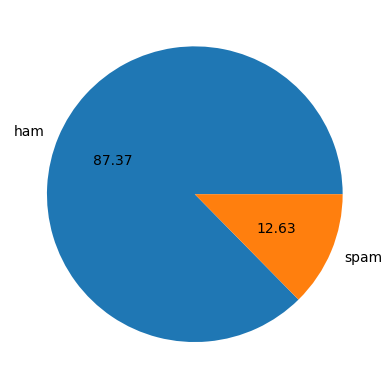

In [75]:
#plot it in a pie chart
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [76]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [77]:
#check for no of characters, words, sentences
df['num_characters']=df['email'].apply(len)
df['num_words']=df['email'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_sentence']=df['email'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [78]:
df.head()

,target,email,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [79]:
#describe for ham messages
df[df['target']==0][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [80]:
#describe for spam messages
df[df['target']==1][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

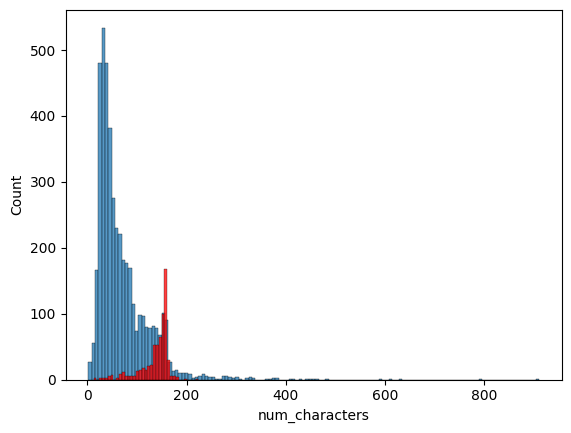

In [81]:
#plot histogram
import seaborn as sns

sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

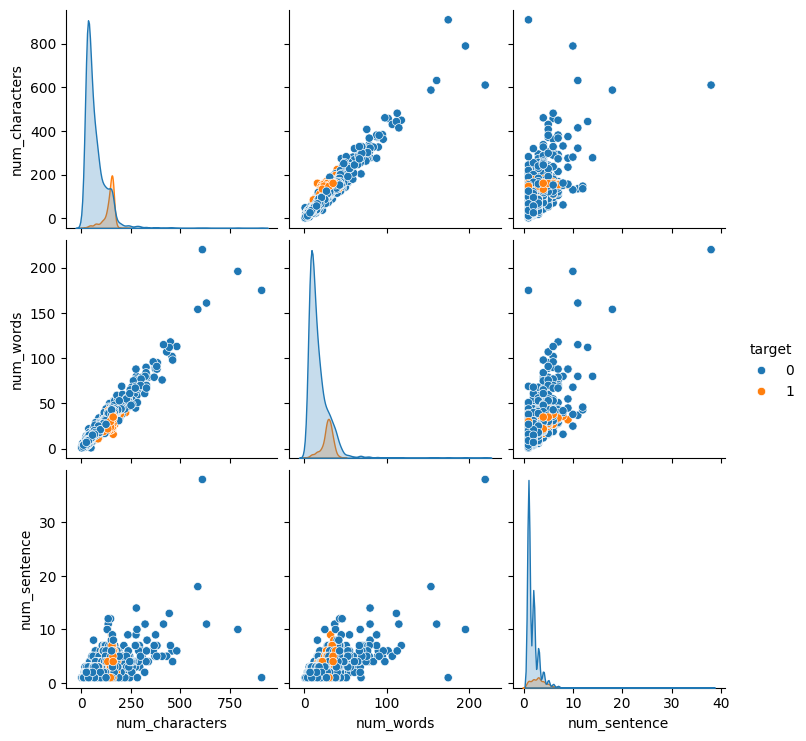

In [82]:
sns.pairplot(df,hue='target')

<Axes: >

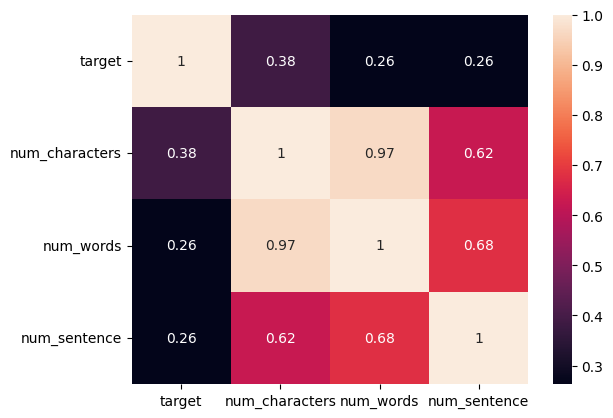

In [83]:
sns.heatmap(df[['target','num_characters','num_words','num_sentence']].corr(),annot=True)

**DATA PREPROCESSING**

*   lowercase
*   tokenization
*   removing special characters, stopwords, punctuations
*   stemming





In [84]:
from nltk.corpus import stopwords
import string
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [85]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [86]:
def transform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)

  #removing special characters
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)

  text=y[:]
  y.clear()

  #removing stopwords and punctuations
  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text=y[:]
  y.clear()

  #apply stemming
  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [87]:
df['transformed_email']=df['email'].apply(transform_text)
df.head()

,target,email,num_characters,num_words,num_sentence,transformed_email
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


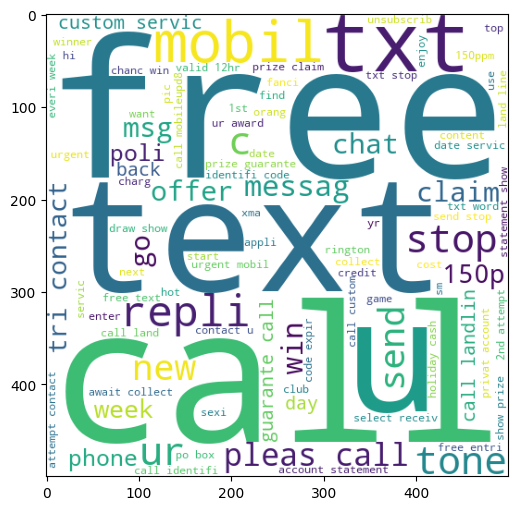

In [88]:
#generate word cloud for spam emails
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

spam_wc=wc.generate(df[df['target']==1]['transformed_email'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

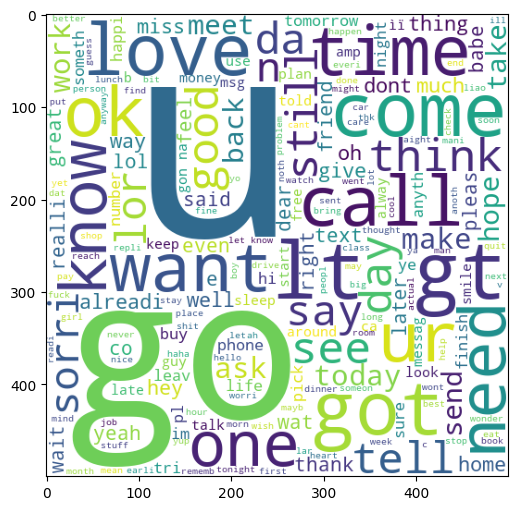

In [89]:
#generate word cloud for ham emails
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

ham_wc=wc.generate(df[df['target']==0]['transformed_email'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [90]:
#find the top 30 words for spam emails
spam_corpus=[]
for msg in df[df['target']==1]['transformed_email'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [91]:
#find the top 30 words for ham emails
ham_corpus=[]
for msg in df[df['target']==0]['transformed_email'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

from collections import Counter
Counter(ham_corpus).most_common(30)

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234),
 ('call', 233),
 ('time', 219),
 ('ok', 217),
 ('love', 216),
 ('good', 213),
 ('want', 208),
 ('ur', 197),
 ('day', 190),
 ('need', 170),
 ('one', 165),
 ('lor', 159),
 ('4', 156),
 ('home', 152),
 ('think', 149),
 ('see', 147),
 ('take', 143),
 ('still', 143),
 ('da', 142),
 ('tell', 133),
 ('make', 129)]

In [92]:
len(spam_corpus)

9939

In [93]:
len(ham_corpus)

35404

**MODEL BUIDLING**

Applying BOW

In [94]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
#tfidf=TfidfVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

X=tfidf.fit_transform(df['transformed_email']).toarray()
y=df['target'].values

In [95]:
#apply scaling
#from sklearn.preprocessing import MinMaxScaler
#scaler=MinMaxScaler()
#X=scaler.fit_transform(X)

In [96]:
#appending num_character column to X
#X=np.hstack((X,df['num_characters'].values.reshape(-1,1)))
#X

In [97]:
X.shape

(5169, 3000)

In [98]:
y.shape

(5169,)

Train Test Split

In [99]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=1)

**NAIVE BAYES ALGORITHM**

In [100]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [101]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [102]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8597678916827853
[[778 121]
 [ 24 111]]
0.47844827586206895


In [103]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9613152804642167
[[899   0]
 [ 40  95]]
1.0


In [104]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[898   1]
 [ 30 105]]
0.9905660377358491


In [105]:
#tfidf --> mbm

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [107]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50, random_state=2)
bc=BaggingClassifier(n_estimators=50, random_state=2)
etc=ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb=XGBClassifier(n_estimators=50, random_state=2)

In [108]:
clfs={
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'BgC':bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb
}


In [109]:
def train_classifier(clfs,X_train,y_train,X_test,y_test):
  clfs.fit(X_train,y_train)
  y_pred=clfs.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)

  return accuracy,precision

In [110]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9690522243713733, 0.9557522123893806)

In [111]:
#store accuracy and precision score for every classifier
accuracy_scores=[]
precison_scores=[]

for name,clf in clfs.items():
  current_accuracy,current_precison=train_classifier(clf,X_train,y_train,X_test,y_test)

  accuracy_scores.append(current_accuracy)
  precison_scores.append(current_precison)

In [112]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precison':precison_scores}).sort_values('Precison',ascending=False)

In [113]:
#performance_df

**MODEL IMPROVEMENT**


*   Change max_features paramater of Tfidf
*   Apply scaling
*   Add num_character column



In [114]:
maxFeature_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precison_max_ft_3000':precison_scores}).sort_values('Precison_max_ft_3000',ascending=False)

maxFeature_df

,Algorithm,Accuracy_max_ft_3000,Precison_max_ft_3000
1,KN,0.913926,1.000000
2,NB,0.961315,1.000000
5,RF,0.968085,1.000000
8,ETC,0.970986,0.981651
0,SVC,0.969052,0.955752
10,xgb,0.954545,0.907407
4,LR,0.941006,0.885417
7,BgC,0.945841,0.837607
9,GBDT,0.934236,0.831683
6,AdaBoost,0.905222,0.753425


In [115]:
#scaling_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precison_scaling':precison_scores}).sort_values('Precison_scaling',ascending=False)

#scaling_df

In [116]:
#num_character_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_char':accuracy_scores,'Precison_num_char':precison_scores}).sort_values('Precison_num_char',ascending=False)

#num_character_df

In [117]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [120]:
print("numpy",np.__version__)
print("pandas",pd.__version__)
print("sklearn",sklearn.__version__)


numpy 1.26.4
pandas 2.3.3
sklearn 1.7.2
